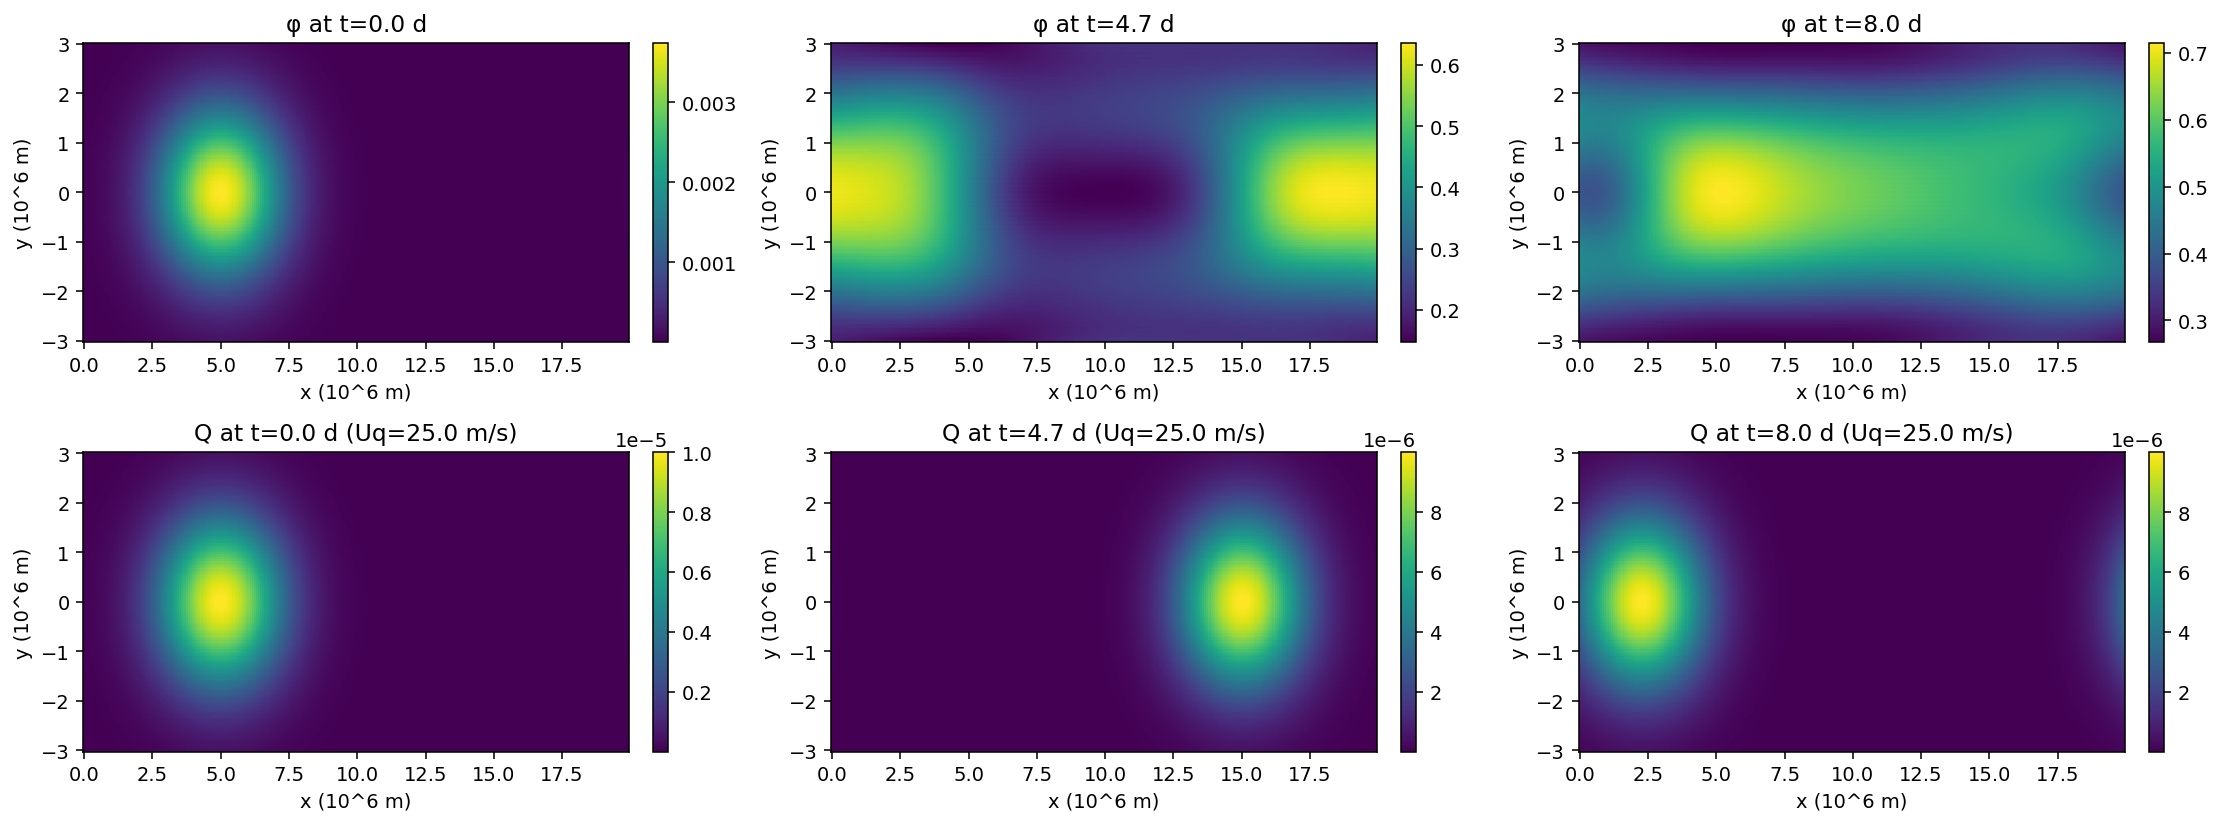

(1.1574074074074074e-06, 25.0, 1e-05, 375.0, 1844)

In [3]:
# Shallow-water β-plane with linear damping and moving Gaussian heating Q
# Additions vs previous:
#  - Linear damping: -eps*u, -eps*v, -eps*phi
#  - Heating Q(y,x,t): Gaussian that moves eastward with user-set speed Uq
#    Q0 [m^2 s^-3], widths sigma_x, sigma_y; periodic in x via wrapped distance.
#
# You can change: eps, Uq, Q0, sigma_x, sigma_y, center latitude yc, etc.

import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Domain, parameters
# -------------------------
c = 50.0                      # gravity wave speed (m/s)
beta = 2.3e-11                # β parameter (1/(m s))
Lx = 2.0e7                    # 20,000 km
Ly = 6.0e6                    # 6,000 km

Nx = 256
Ny = 129
dx = Lx / Nx
dy = Ly / (Ny - 1)

x = np.linspace(0, Lx - dx, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)
Y = y[:, None] * np.ones((1, Nx))

# FFT wavenumbers for x-derivatives
kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
ikx = 1j * kx

# Time control
tmax = 8 * 24 * 3600.0        # 8 days
# CFL with gravity wave and advection of heating; include Uq later after it's defined
# We'll compute dt after defining heating speed below.
# -------------------------
# 2) Damping & Heating parameters (user-editable)
# -------------------------
eps = 1.0 / (10.0 * 24 * 3600.0)   # linear damping rate: 10-day e-folding
Uq = 25.0                          # eastward heating propagation speed (m/s)  <-- change this
Q0 = 1.0e-5                        # amplitude of Q (m^2 s^-3)
sigma_x = 0.08 * Lx
sigma_y = 0.20 * Ly
x0 = 0.25 * Lx
yc = 0.0

# Now set dt with both c and Uq (safety factor 0.4)
dt_cfl = 0.4 * min(dx, dy) / max(c, abs(Uq))
dt = dt_cfl
nsteps = int(np.ceil(tmax / dt))

# -------------------------
# 3) Helpers
# -------------------------
def ddx_periodic(F):
    Fhat = np.fft.fft(F, axis=1)
    return np.fft.ifft(ikx * Fhat, axis=1).real

def ddy_bounded(F):
    Fg_top = F[1:2, :]
    Fg_bot = F[-2:-1, :]
    Fext = np.vstack([Fg_top, F, Fg_bot])
    return (Fext[2:, :] - Fext[:-2, :]) / (2 * dy)

def apply_wall_bcs(u, v, phi):
    v[0, :], v[-1, :] = 0.0, 0.0
    u[0, :], u[-1, :] = u[1, :], u[-2, :]
    phi[0, :], phi[-1, :] = phi[1, :], phi[-2, :]

def Q_forcing(t):
    """Moving Gaussian heating, periodic in x via wrapped distance."""
    xc = (x0 + Uq * t) % Lx
    X = np.ones((Ny, 1)) * x[None, :]
    # minimal periodic distance
    dxp = np.abs(X - xc)
    dxp = np.minimum(dxp, Lx - dxp)
    return Q0 * np.exp(-(dxp**2)/(2*sigma_x**2) - ((Y - yc)**2)/(2*sigma_y**2))

# -------------------------
# 4) Tendencies with damping and heating
# -------------------------
def tendencies(u, v, phi, t):
    phix = ddx_periodic(phi)
    phiy = ddy_bounded(phi)
    ux   = ddx_periodic(u)
    vy   = ddy_bounded(v)
    by = beta * Y
    Q = Q_forcing(t)
    du = -phix + by * v - eps * u
    dv = -phiy - by * u - eps * v
    dphi = -c**2 * (ux + vy) - eps * phi + Q
    # Clean tendencies at walls
    du[0, :], du[-1, :] = du[1, :], du[-2, :]
    dv[0, :], dv[-1, :] = 0.0, 0.0
    dphi[0, :], dphi[-1, :] = dphi[1, :], dphi[-2, :]
    return du, dv, dphi, Q

# -------------------------
# 5) Initial condition: rest state (u=v=φ=0)
# -------------------------
u = np.zeros((Ny, Nx))
v = np.zeros((Ny, Nx))
phi = np.zeros((Ny, Nx))
apply_wall_bcs(u, v, phi)

# -------------------------
# 6) Time stepping (RK4) and snapshots
# -------------------------
nout = 12
sample_every = max(1, nsteps // nout)
snap_phi = []
snap_Q = []

t = 0.0
for n in range(nsteps):
    du1, dv1, dphi1, Q1 = tendencies(u, v, phi, t)
    u1 = u + 0.5 * dt * du1; v1 = v + 0.5 * dt * dv1; phi1 = phi + 0.5 * dt * dphi1
    apply_wall_bcs(u1, v1, phi1)

    du2, dv2, dphi2, _ = tendencies(u1, v1, phi1, t + 0.5*dt)
    u2 = u + 0.5 * dt * du2; v2 = v + 0.5 * dt * dv2; phi2 = phi + 0.5 * dt * dphi2
    apply_wall_bcs(u2, v2, phi2)

    du3, dv3, dphi3, _ = tendencies(u2, v2, phi2, t + 0.5*dt)
    u3 = u + dt * du3; v3 = v + dt * dv3; phi3 = phi + dt * dphi3
    apply_wall_bcs(u3, v3, phi3)

    du4, dv4, dphi4, _ = tendencies(u3, v3, phi3, t + dt)

    u += (dt / 6.0) * (du1 + 2*du2 + 2*du3 + du4)
    v += (dt / 6.0) * (dv1 + 2*dv2 + 2*dv3 + dv4)
    phi += (dt / 6.0) * (dphi1 + 2*dphi2 + 2*dphi3 + dphi4)
    apply_wall_bcs(u, v, phi)

    t += dt
    if (n % sample_every) == 0 or n == nsteps - 1:
        snap_phi.append((t, phi.copy()))
        snap_Q.append((t, Q1.copy()))

# -------------------------
# 7) Plot φ and Q snapshots at start, middle, end
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 6), dpi=140)

for col, (ti, phii) in enumerate([snap_phi[0], snap_phi[len(snap_phi)//2], snap_phi[-1]]):
    im1 = axes[0, col].pcolormesh(x/1e6, y/1e6, phii, shading='auto')
    axes[0, col].set_title(f'φ at t={ti/86400:.1f} d')
    axes[0, col].set_xlabel('x (10^6 m)'); axes[0, col].set_ylabel('y (10^6 m)')
    fig.colorbar(im1, ax=axes[0, col], fraction=0.046, pad=0.04)

for col, (ti, Qi) in enumerate([snap_Q[0], snap_Q[len(snap_Q)//2], snap_Q[-1]]):
    im2 = axes[1, col].pcolormesh(x/1e6, y/1e6, Qi, shading='auto')
    axes[1, col].set_title(f'Q at t={ti/86400:.1f} d (Uq={Uq} m/s)')
    axes[1, col].set_xlabel('x (10^6 m)'); axes[1, col].set_ylabel('y (10^6 m)')
    fig.colorbar(im2, ax=axes[1, col], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

# Expose key knobs back to the user
(eps, Uq, Q0, dt, nsteps)
